In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [2]:
# Libraries
import numpy as np
import re
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
import networkx as nx
from adjustText import adjust_text

import gc
import re
import random
import math

import stringdb
import string
import logging

import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.colors import Normalize, LinearSegmentedColormap

import igraph as ig
import leidenalg

In [4]:
gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_go = pd.read_excel("../../PASNet/Output/GO/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/GO/pt_fixed_ens.xlsx", index_col=0)

sc1_go.columns = pt.columns
sc1_go.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_go.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_go = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_go = df_go[df_go['Weight'] != 0]

gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_rest = pd.read_excel("../../PASNet/Output/REST/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/REST/pt_fixed_ens.xlsx", index_col=0)

sc1_rest.columns = pt.columns
sc1_rest.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_rest.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_rest = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_rest = df_rest[df_rest['Weight'] != 0]

df = pd.concat([df_go, df_rest], ignore_index=True)
df['source'] = df['source'].str.replace(r' (\(GO|WP|R-HSA).*$', '', regex=True)

pasnet_genes = df['target'].unique()
len(pasnet_genes)

2220

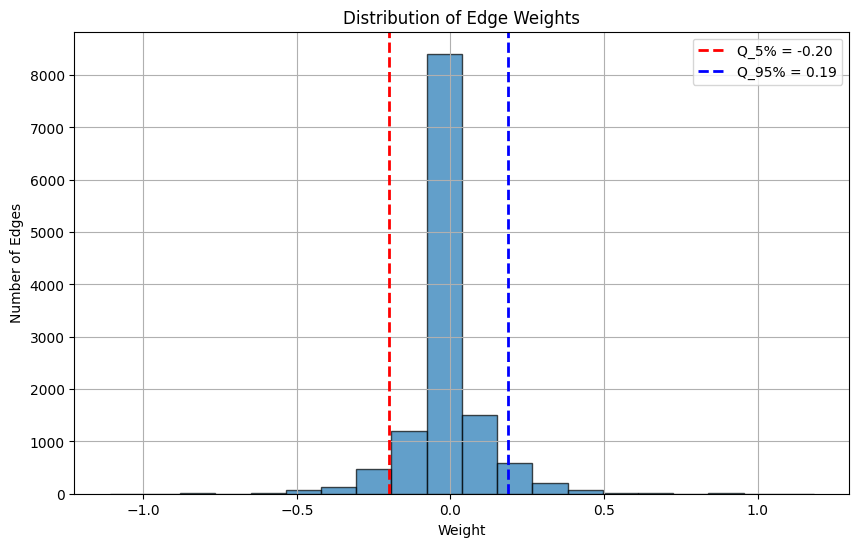

In [5]:
# Assuming your DataFrame is named df and has a 'Weight' column
weight_values = df['Weight']

# Calculate Q1 and Q3
q1 = weight_values.quantile(0.05)
q3 = weight_values.quantile(0.95)

plt.figure(figsize=(10, 6))
plt.hist(weight_values, bins=20, edgecolor='black', alpha=0.7)

# Add vertical lines for Q1 and Q3
plt.axvline(x=q1, color='red', linestyle='--', linewidth=2, label=f'Q_5% = {q1:.2f}')
plt.axvline(x=q3, color='blue', linestyle='--', linewidth=2, label=f'Q_95% = {q3:.2f}')

plt.title('Distribution of Edge Weights')
plt.xlabel('Weight')
plt.ylabel('Number of Edges')
plt.grid(True)
plt.legend()
plt.show()

In [6]:
df = df[(df['Weight'] > 0.19) | (df['Weight'] < -0.20)]

In [7]:
#Harmonizing with the SJARACNe file format that is to follow
genes_list = pd.concat([df['source'], df['target']]).unique().tolist()

df['MI'] = None
df['spearman'] = None
df['p-value'] = None

In [8]:
df_sj_sig = pd.read_csv("../../results/TCGA/SJARACNe_networks/output_sig_sjaracne_Prostate_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_tf = pd.read_csv("../../results/TCGA/SJARACNe_networks/output_tf_sjaracne_Prostate_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_nc = pd.read_csv("../../results/TCGA/SJARACNe_networks/output_nc_sjaracne_Prostate_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')

# Row binding the two dataframes
df_sj = pd.concat([df_sj_sig, df_sj_tf, df_sj_nc], axis=0, ignore_index=True)

# Removing duplicates based on columns "source" and "target"
df_sj = df_sj.drop_duplicates(subset=['source', 'target'])

# Keep only the specified columns: source, label, MI, spearman, p-value
columns_to_keep = ['source', 'target', 'MI', 'spearman', 'p-value']
df_sj = df_sj[columns_to_keep]

#Harmonizing with PASNet outputs
df_sj['Weight'] = None
df_sj = df_sj[df_sj['p-value'] <= 0.05]

df_sj['sorted_pair'] = df_sj.apply(lambda row: tuple(sorted([row['source'], row['target']])), axis=1)
df_sj = df_sj.sort_values(by='MI', ascending=False).drop_duplicates(subset=['sorted_pair']).drop(columns=['sorted_pair'])

combined_df_net = pd.concat([df, df_sj], ignore_index=True)
len(combined_df_net)

FileNotFoundError: [Errno 2] No such file or directory: '../../results/TCGA/SJARACNe_networks/output_sig_sjaracne_TCGA_NetBID2_out_.final/consensus_network_ncol_.txt'

In [17]:
# assuming your dataframe is named df

# rows where source == "LINC00158"
df_source = combined_df_net[combined_df_net["source"] == "LINC00158"]

# rows where target == "LINC00158"
df_target = combined_df_net[combined_df_net["target"] == "LINC00158"]

# if you want to combine them back into one dataframe:
df_linc00158 = pd.concat([df_source, df_target])

In [8]:
res_icgc = pd.read_excel("../../results/ICGC/ICGC_NetBID2_ms_tab.xlsx")
res_icgc = res_icgc[['originalID', 'funcType', 'Size', 'logFC.U.Vs.M_DA', 'adj.P.Val.U.Vs.M_DA', 'Z.U.Vs.M_DA', 'logFC.U.Vs.M_DE', 'adj.P.Val.U.Vs.M_DE', 'Z.U.Vs.M_DE']]
res_icgc.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.U.Vs.M_DA': 'logFC_DA',
    'adj.P.Val.U.Vs.M_DA': 'adj.P.Val_DA',
    'Z.U.Vs.M_DA': 'Z-score_DA',
    'logFC.U.Vs.M_DE': 'logFC_DE',
    'adj.P.Val.U.Vs.M_DE': 'adj.P.Val_DE',
    'Z.U.Vs.M_DE': 'Z-score_DE',
}, inplace=True)

# Create a temporary column to give priority to "TF" rows
res_icgc['priority'] = res_icgc['Type'].apply(lambda x: 0 if x == 'TF' else 1)

# Sort the DataFrame by the 'priority' column (TF first) and by ID to make sure we keep the first occurrence
res_icgc = res_icgc.sort_values(by=['priority', 'ID'])

# Remove duplicated rows by 'ID', keeping the first occurrence (which should be the "TF" if it's present)
res_icgc = res_icgc.drop_duplicates(subset='ID', keep='first')

res_icgc = res_icgc.drop(columns=['priority'])

res_icgc_filt_overt = res_icgc[
    (res_icgc['adj.P.Val_DA'] < 0.05) &
    (res_icgc['adj.P.Val_DE'] < 0.05) &
    (res_icgc['Size'] > 30)
]

res_icgc_filt_hidden = res_icgc[
    (res_icgc['adj.P.Val_DA'] < 0.05) &
    (res_icgc['adj.P.Val_DE'] > 0.05) &
    (res_icgc['Size'] > 30)
]

print("Overt Drivers:", len(res_icgc_filt_overt), "\n"
      "Hidden_Drivers:", len(res_icgc_filt_hidden), "\n"
      "Overt TFs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "TF"]), "\n"
      "Overt SIGs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "SIG"]), "\n"
      "Overt NCs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "NC"]), "\n"
      "Hidden TFs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "TF"]), "\n"
      "Hidden SIGs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "SIG"]), "\n"
      "Hidden NCs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "NC"]))

Overt Drivers: 793 
Hidden_Drivers: 1070 
Overt TFs: 185 
Overt SIGs: 293 
Overt NCs: 315 
Hidden TFs: 273 
Hidden SIGs: 400 
Hidden NCs: 397


In [9]:
shap_validation = pd.read_csv("../../PASNet/Output/GO/feature_importance_table_icgc_validation.csv", index_col=0)
shap_validation_top20 = shap_validation.sort_values(by="Importance", ascending=False).head(20)

shap_testing = pd.read_csv("../../PASNet/Output/GO/feature_importance_table_bcmo_testing.csv", index_col=0)
shap_testing_top20 = shap_testing.sort_values(by="Importance", ascending=False).head(20)

combined_df = pd.concat([shap_validation_top20, shap_testing_top20], axis=0)
combined_df = combined_df.sort_values(by="Importance", ascending=False)
combined_df_go = combined_df[~combined_df.index.duplicated(keep='first')]

shap_validation = pd.read_csv("../../PASNet/Output/REST/feature_importance_table_icgc_validation.csv", index_col=0)
shap_validation_top20 = shap_validation.sort_values(by="Importance", ascending=False).head(20)

shap_testing = pd.read_csv("../../PASNet/Output/REST/feature_importance_table_bcmo_testing.csv", index_col=0)
shap_testing_top20 = shap_testing.sort_values(by="Importance", ascending=False).head(20)

combined_df = pd.concat([shap_validation_top20, shap_testing_top20], axis=0)
combined_df = combined_df.sort_values(by="Importance", ascending=False)
combined_df_rest = combined_df[~combined_df.index.duplicated(keep='first')]

In [10]:
# Step 1: Get the feature names (index) from both DataFrames
features_rest = combined_df_rest.index
features_go = combined_df_go.index

# Step 2: Combine the feature names
combined_features = features_rest.to_list() + features_go.to_list()

# Step 3: Remove duplicates
unique_features = pd.Index(combined_features).unique()

# Optional: Convert to DataFrame if needed
features_df = pd.DataFrame(unique_features, columns=['Feature'])

In [11]:
res_icgc_filt = res_icgc[res_icgc['ID'].isin(features_df['Feature'])]
len(res_icgc_filt)

49

In [12]:
weights = df['source'].unique()
weights_df = pd.DataFrame({
    'ID': weights,
    'Type': "Pathway",
    'Size': np.nan,
    'logFC_DA': np.nan,
    'adj.P.Val_DA': np.nan,
    'Z-score_DA' : np.nan,
    'logFC_DE': np.nan,
    'adj.P.Val_DE': np.nan,
    'Z-score_DE': np.nan
})

node_combined = pd.concat([res_icgc_filt, weights_df], ignore_index=True)
len(node_combined)

110

In [13]:
# Step 1: Read the DataFrame with the edge connections
df_edges = combined_df_net

# Step 2: Read the DataFrame with node attributes
df_node_attributes = node_combined

#df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) | df_edges['target'].isin(df_node_attributes['ID'])]
df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) & df_edges['target'].isin(df_node_attributes['ID'])]

# Step 3: Create a undirected graph
G = nx.Graph()

# Step 4: Add edges to the graph
for index, row in df_edges.iterrows():
    source = row['source']
    target = row['target']
    attributes = row.drop(['source', 'target'])  # Extract edge attributes
    G.add_edge(source, target, **attributes)  # Add edge with attributes

# Step 5: Transfer node attributes
for index, row in df_node_attributes.iterrows():
    node_name = row['ID']
    if node_name in G.nodes:
        attributes = row.drop('ID')  # Remove the node name to keep only the attributes
        G.nodes[node_name].update(attributes)

# Add a new attribute 'label' with node names
for node in G.nodes:
    G.nodes[node]['label'] = str(node)  # Set 'label' attribute to node name (convert to string if needed)

print(f"Edges: {len(G.edges)}")
print(f"Nodes: {len(G.nodes)}")

Edges: 230
Nodes: 66


In [16]:
path = nx.shortest_path(G, source="LINC00158", target="LPL")

In [18]:
path = nx.shortest_path(G, source="LINC00158", target="LPL", weight='ΜΙ')
print(path)

['LINC00158', 'KCNJ2-AS1', 'LPL']


Shortest path: ['LINC00158', 'KCNJ2-AS1', 'LPL']


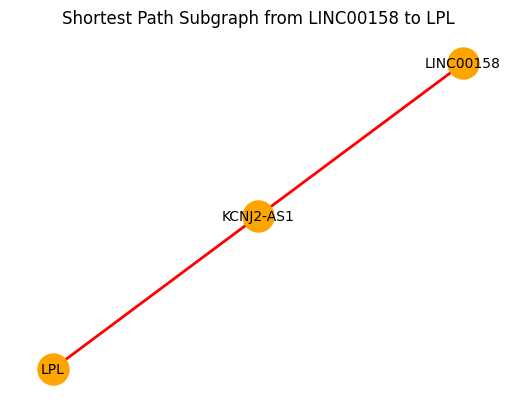

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

# Example: assume G is your existing NetworkX graph
# G = nx.Graph()
# Add nodes and edges as needed
# G.add_edge("LINC00158", "GeneA")
# G.add_edge("GeneA", "LPL")

# 1. Check nodes exist
if "LINC00158" not in G.nodes or "LPL" not in G.nodes:
    print("One or both nodes are not in the graph.")
else:
    # 2. Find shortest path
    try:
        shortest_path = nx.shortest_path(G, source="LINC00158", target="LPL")
        print("Shortest path:", shortest_path)
    except nx.NetworkXNoPath:
        print("No path exists between LINC00158 and LPL.")
        shortest_path = []

    if shortest_path:
        # 3. Create a subgraph with only the shortest path nodes and edges
        path_edges = list(zip(shortest_path, shortest_path[1:]))
        H = nx.Graph()  # new graph for the path
        H.add_nodes_from(shortest_path)
        H.add_edges_from(path_edges)

        # 4. Draw the subgraph
        pos = nx.spring_layout(H, seed=42)
        nx.draw_networkx_nodes(H, pos, node_color='orange', node_size=500)
        nx.draw_networkx_edges(H, pos, edge_color='red', width=2)
        nx.draw_networkx_labels(H, pos, font_size=10)

        plt.title("Shortest Path Subgraph from LINC00158 to LPL")
        plt.axis('off')
        plt.show()
